# 3. Backtest & Performance Evaluation

Backtest individual signals and the composite signal with realistic assumptions:
- Transaction costs from 0 bps (gross) to 2+ bps (taker fees)
- 1-bar signal delay (trade at next bar's close after signal generation)
- Position sizing: continuous (proportional to signal) and thresholded (discrete {-1,0,+1})
- Rebalance frequency sweep to match 5–15 min target holding period
- Walk-forward validation to detect overfitting

In [14]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

from src.data import load_raw_trades, aggregate_ohlcv
from src import signals as sig
from src.backtest import run_backtest, walk_forward_backtest

In [15]:
trades = load_raw_trades()
bars = aggregate_ohlcv(trades, '1min')
all_signals = sig.composite_signal(bars)
print(f"Bars: {len(bars)}, Signals: {list(all_signals.columns)}")

Bars: 2880, Signals: ['zscore_mr', 'bollinger_mr', 'vwap_mr', 'ofi', 'trade_intensity', 'rsi_mr', 'ma_cross', 'vol_momentum', 'composite_raw', 'composite', 'position']


## 3.1 Gross Alpha: Individual Signal Backtests (0 bps)

First, check gross PnL (no transaction costs) to confirm signals have real predictive power.

In [16]:
signal_names = [c for c in all_signals.columns if c not in ('composite', 'composite_raw', 'position')]
results_gross = {}
results_net = {}

for name in signal_names + ['composite']:
    s = all_signals[name].clip(-1, 1)
    results_gross[name] = run_backtest(bars, s, cost_bps=0.0)
    results_net[name] = run_backtest(bars, s, cost_bps=2.0)

# Summary table
rows = []
for name in signal_names + ['composite']:
    g = results_gross[name].metrics
    n = results_net[name].metrics
    rows.append({
        'signal': name,
        'gross_pnl': g['total_pnl'],
        'gross_sharpe': g['sharpe_annualized'],
        'net_pnl_2bps': n['total_pnl'],
        'net_sharpe_2bps': n['sharpe_annualized'],
        'turnover': g['total_turnover'],
        'profit_factor_gross': g['profit_factor'],
        'win_rate': g['win_rate'],
    })

metrics_df = pd.DataFrame(rows).set_index('signal').round(4)
print("Signal Performance: Gross vs Net (2 bps)")
metrics_df

Signal Performance: Gross vs Net (2 bps)


,gross_pnl,gross_sharpe,net_pnl_2bps,net_sharpe_2bps,turnover,profit_factor_gross,win_rate
signal,,,,,,,
zscore_mr,0.0306,34.8974,-0.1110,-118.8578,708.1745,1.1596,0.5194
bollinger_mr,0.0266,40.4222,-0.0981,-143.0878,623.3909,1.2062,0.5194
vwap_mr,0.0343,39.7084,-0.1297,-138.4640,819.8765,1.1852,0.5219
ofi,0.0446,56.1496,-0.1517,-178.0045,981.6492,1.2824,0.5039
trade_intensity,0.0010,1.3507,-0.4235,-505.3781,2122.4901,1.0062,0.5134
rsi_mr,0.0363,49.1397,-0.1171,-150.2687,766.8775,1.2572,0.5233
ma_cross,0.0257,39.8253,-0.0489,-74.8525,373.1134,1.1975,0.5291
vol_momentum,0.0258,32.4643,-0.0960,-113.4499,608.8351,1.1533,0.5140
composite,0.0300,43.1719,-0.0443,-63.1531,371.3411,1.2161,0.5179


## 3.2 Cumulative Gross PnL

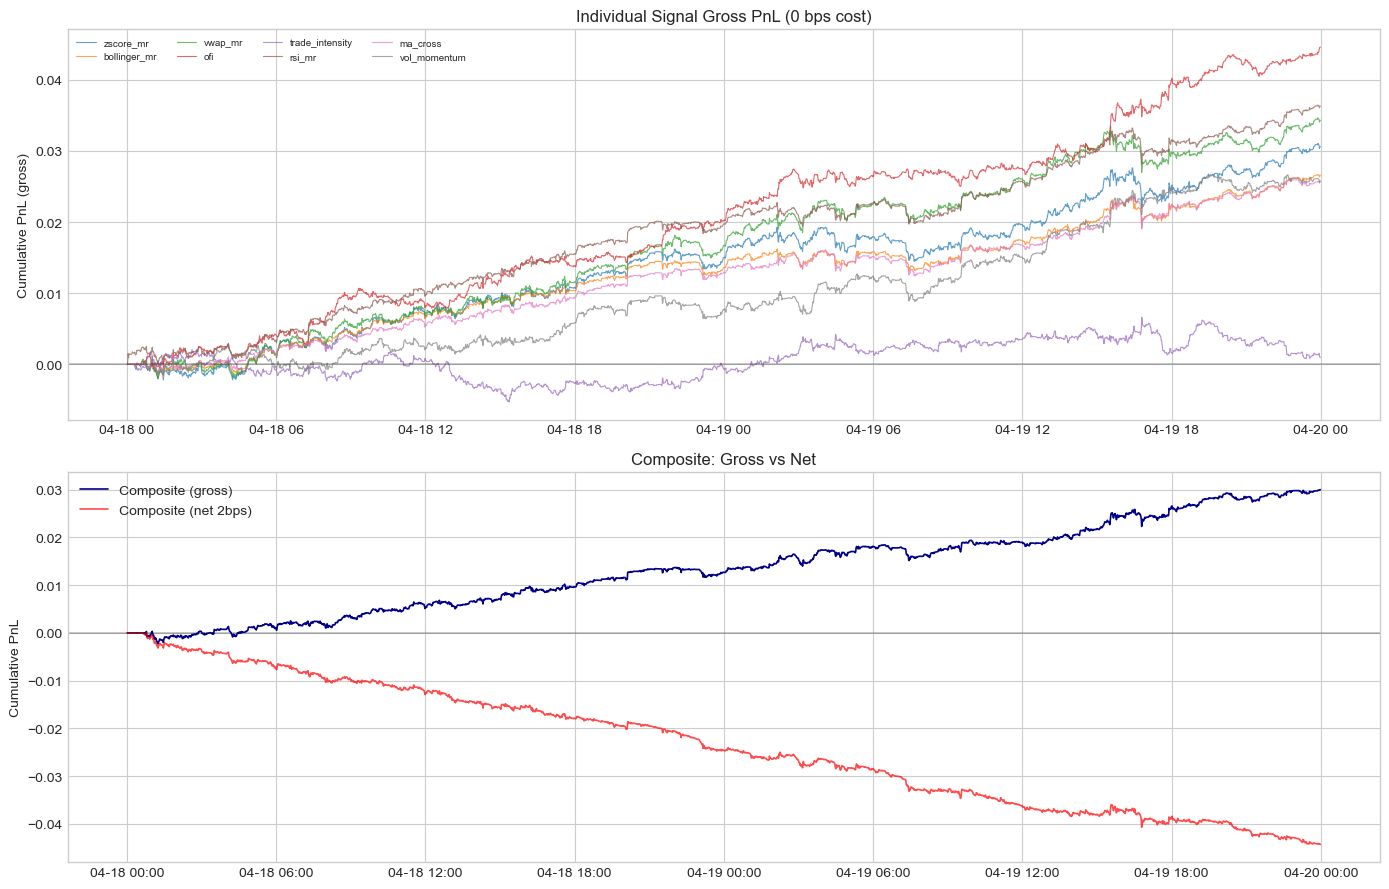

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for name in signal_names:
    r = results_gross[name]
    axes[0].plot(r.cumulative_pnl.index, r.cumulative_pnl.values, 
                 linewidth=0.8, label=name, alpha=0.7)
axes[0].set_ylabel('Cumulative PnL (gross)')
axes[0].set_title('Individual Signal Gross PnL (0 bps cost)')
axes[0].legend(fontsize=7, ncol=4)
axes[0].axhline(0, color='black', linewidth=0.3)

r_comp = results_gross['composite']
r_comp_net = results_net['composite']
axes[1].plot(r_comp.cumulative_pnl.index, r_comp.cumulative_pnl.values, 
             linewidth=1.2, color='darkblue', label='Composite (gross)')
axes[1].plot(r_comp_net.cumulative_pnl.index, r_comp_net.cumulative_pnl.values, 
             linewidth=1.2, color='red', alpha=0.7, label='Composite (net 2bps)')
axes[1].set_ylabel('Cumulative PnL')
axes[1].set_title('Composite: Gross vs Net')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 3.3 Transaction Cost Sensitivity

The critical question: at what cost level does the strategy break even?

Binance fee tiers:
- Regular taker: ~4-5 bps
- VIP taker: ~2 bps  
- VIP maker: **negative** (rebate) to ~0.5 bps
- Post-only / maker strategy: effectively 0 or negative

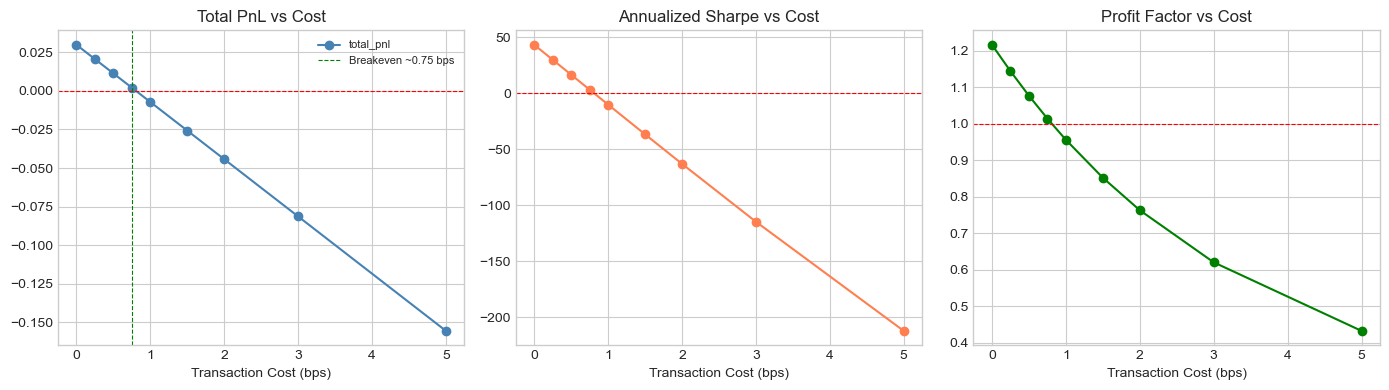

Cost Sensitivity Table:


,total_pnl,sharpe,profit_factor
cost_bps,,,
0.00,0.0300,43.1719,1.2161
0.25,0.0207,29.8061,1.1439
0.50,0.0114,16.4392,1.0765
0.75,0.0021,3.0827,1.0138
1.00,-0.0071,-10.2522,0.9557
1.50,-0.0257,-36.8123,0.8518
2.00,-0.0443,-63.1531,0.7628
3.00,-0.0814,-114.8473,0.6201
5.00,-0.1557,-212.3182,0.4323


In [18]:
cost_levels = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
cost_results = []

composite_sig = all_signals['composite'].clip(-1, 1)

for cost in cost_levels:
    r = run_backtest(bars, composite_sig, cost_bps=cost)
    cost_results.append({
        'cost_bps': cost,
        'total_pnl': r.metrics['total_pnl'],
        'sharpe': r.metrics['sharpe_annualized'],
        'profit_factor': r.metrics['profit_factor'],
    })

cost_df = pd.DataFrame(cost_results).set_index('cost_bps')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cost_df['total_pnl'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Total PnL vs Cost')
axes[0].set_xlabel('Transaction Cost (bps)')
axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0].axvline(0.75, color='green', linewidth=0.8, linestyle='--', label='Breakeven ~0.75 bps')
axes[0].legend(fontsize=8)

cost_df['sharpe'].plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Annualized Sharpe vs Cost')
axes[1].set_xlabel('Transaction Cost (bps)')
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')

cost_df['profit_factor'].plot(ax=axes[2], marker='o', color='green')
axes[2].set_title('Profit Factor vs Cost')
axes[2].set_xlabel('Transaction Cost (bps)')
axes[2].axhline(1, color='red', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print("Cost Sensitivity Table:")
cost_df.round(4)

## 3.4 Rebalance Frequency: Matching the Holding Period

Signals are computed on 1-min bars, but the target holding period is 5–15 min.
Rebalancing less frequently reduces turnover at the cost of some signal decay.

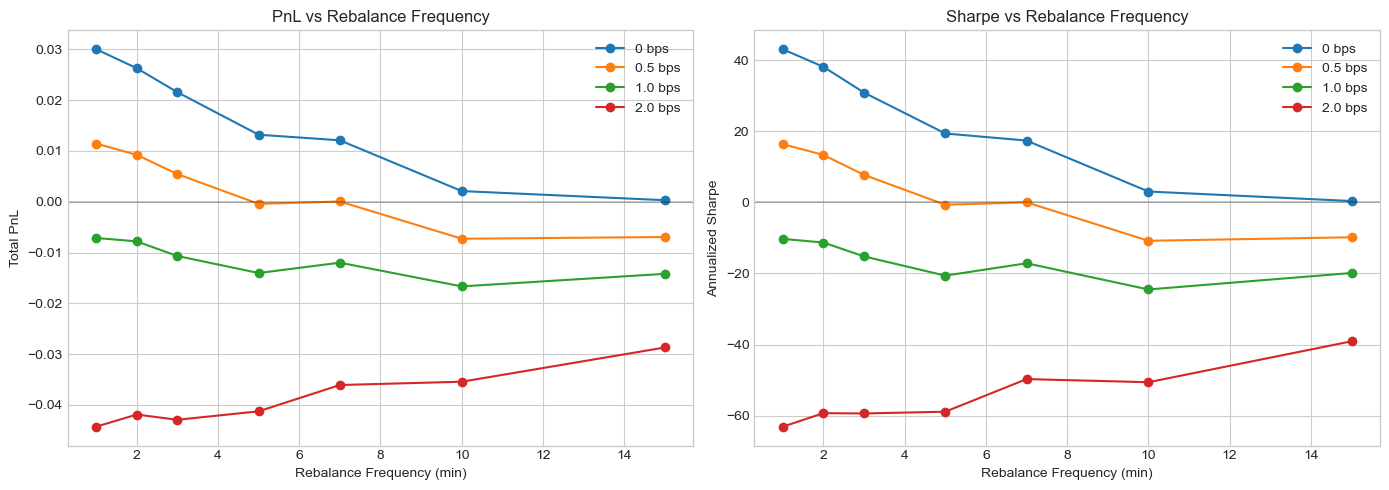

Annualized Sharpe by Rebalance Freq × Cost:


cost_bps,0.0,0.5,1.0,2.0
rebal_min,,,,
1,43.2,16.4,-10.3,-63.2
2,38.2,13.4,-11.3,-59.3
3,30.9,7.8,-15.2,-59.4
5,19.4,-0.6,-20.6,-58.9
7,17.4,0.0,-17.1,-49.7
10,3.1,-10.8,-24.5,-50.6
15,0.4,-9.8,-19.9,-39.1


In [19]:
rebalance_results = []

for freq in [1, 2, 3, 5, 7, 10, 15]:
    for cost in [0, 0.5, 1.0, 2.0]:
        r = run_backtest(bars, composite_sig, cost_bps=cost, rebalance_freq=freq)
        rebalance_results.append({
            'rebal_min': freq,
            'cost_bps': cost,
            'total_pnl': r.metrics['total_pnl'],
            'sharpe': r.metrics['sharpe_annualized'],
            'turnover': r.metrics['total_turnover'],
        })

rb_df = pd.DataFrame(rebalance_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cost in [0, 0.5, 1.0, 2.0]:
    subset = rb_df[rb_df['cost_bps'] == cost]
    axes[0].plot(subset['rebal_min'], subset['total_pnl'], marker='o', label=f'{cost} bps')
    axes[1].plot(subset['rebal_min'], subset['sharpe'], marker='o', label=f'{cost} bps')

axes[0].set_xlabel('Rebalance Frequency (min)')
axes[0].set_ylabel('Total PnL')
axes[0].set_title('PnL vs Rebalance Frequency')
axes[0].axhline(0, color='black', linewidth=0.3)
axes[0].legend()

axes[1].set_xlabel('Rebalance Frequency (min)')
axes[1].set_ylabel('Annualized Sharpe')
axes[1].set_title('Sharpe vs Rebalance Frequency')
axes[1].axhline(0, color='black', linewidth=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Pivoted view
pivot = rb_df.pivot_table(index='rebal_min', columns='cost_bps', values='sharpe').round(1)
print("Annualized Sharpe by Rebalance Freq × Cost:")
pivot

## 3.5 Thresholded (Discrete) Position Strategy

Instead of continuous position sizing, use a hysteresis-based scheme:
enter at signal > threshold, exit when signal decays. This naturally creates the 5-15 min holds.

In [20]:
# Thresholded position is pre-computed in the signal module
pos = all_signals['position']
print(f"Position distribution:")
print(pos.value_counts().sort_index())

# Compute average holding period
pos_changes = pos.diff().abs()
n_trades = (pos_changes > 0).sum()
in_market_bars = (pos != 0).sum()
avg_hold = in_market_bars / max(n_trades / 2, 1)  # divide by 2 for entry+exit
print(f"\nNumber of position changes: {n_trades}")
print(f"Average holding period: {avg_hold:.1f} bars (~minutes)")

Position distribution:
position
-1.0    1356
 0.0     294
 1.0    1230
Name: count, dtype: int64

Number of position changes: 351
Average holding period: 14.7 bars (~minutes)


In [21]:
# Backtest thresholded position at various costs
thresh_results = []
for cost in [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    r = run_backtest(bars, pos, cost_bps=cost)
    thresh_results.append({
        'cost_bps': cost,
        'total_pnl': r.metrics['total_pnl'],
        'sharpe': r.metrics['sharpe_annualized'],
        'profit_factor': r.metrics['profit_factor'],
        'turnover': r.metrics['total_turnover'],
        'win_rate': r.metrics['win_rate'],
    })

thresh_df = pd.DataFrame(thresh_results).set_index('cost_bps')
print("Thresholded Position: Cost Sensitivity")
thresh_df.round(4)

Thresholded Position: Cost Sensitivity


,total_pnl,sharpe,profit_factor,turnover,win_rate
cost_bps,,,,,
0.00,0.0331,33.0860,1.1456,391.0,0.5245
0.25,0.0233,23.2814,1.0994,391.0,0.4877
0.50,0.0136,13.4900,1.0559,391.0,0.4839
0.75,0.0038,3.7528,1.0151,391.0,0.4805
1.00,-0.0060,-5.8903,0.9769,391.0,0.4778
1.50,-0.0255,-24.7482,0.9075,391.0,0.4721
2.00,-0.0451,-42.8241,0.8465,391.0,0.4702
3.00,-0.0842,-75.8969,0.7452,391.0,0.4653


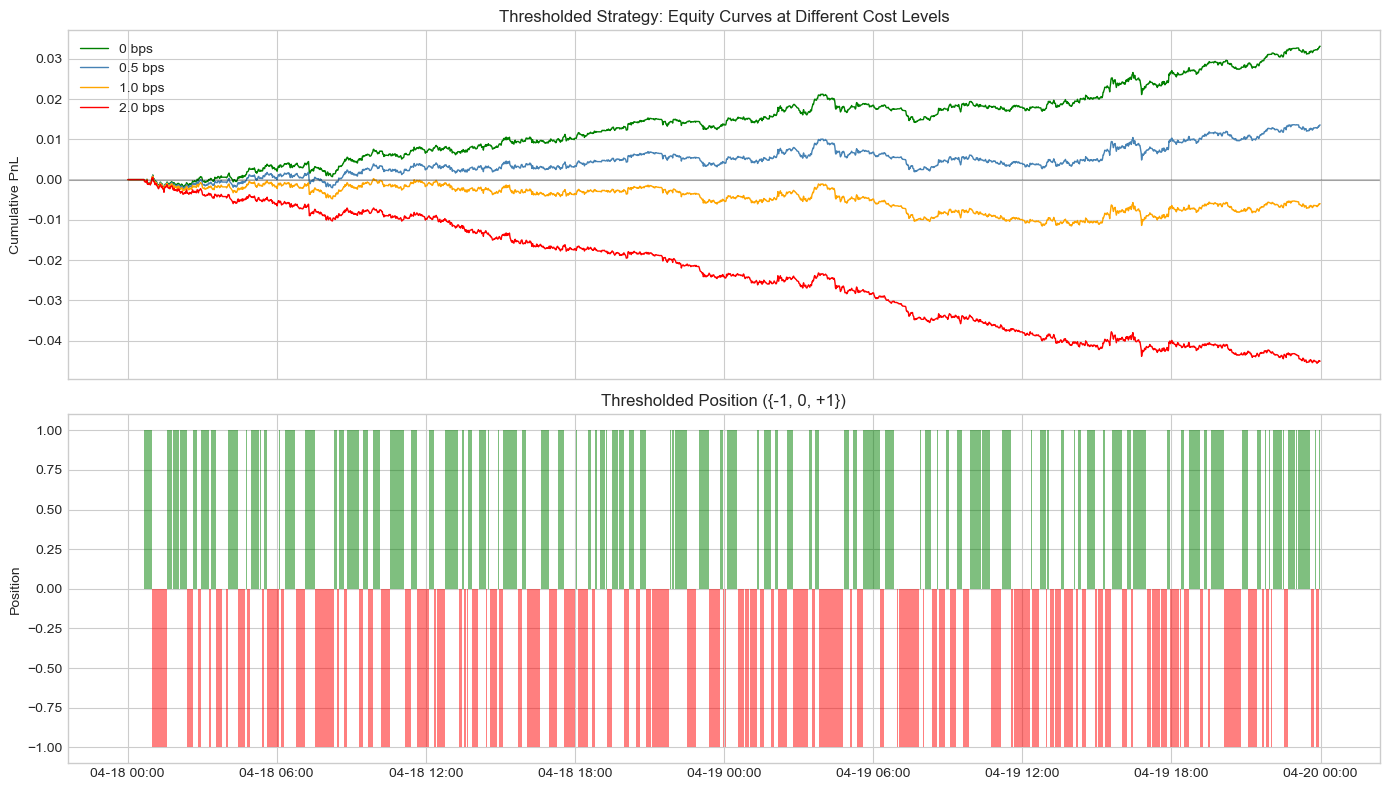

In [22]:
# Equity curves: thresholded at key cost levels
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for cost, color in [(0, 'green'), (0.5, 'steelblue'), (1.0, 'orange'), (2.0, 'red')]:
    r = run_backtest(bars, pos, cost_bps=cost)
    axes[0].plot(r.cumulative_pnl.index, r.cumulative_pnl.values, 
                 linewidth=1, color=color, label=f'{cost} bps')

axes[0].set_ylabel('Cumulative PnL')
axes[0].set_title('Thresholded Strategy: Equity Curves at Different Cost Levels')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.3)

# Position over time
colors_pos = np.where(pos > 0, 'green', np.where(pos < 0, 'red', 'gray'))
axes[1].bar(pos.index, pos.values, width=1/1440, color=colors_pos, alpha=0.5)
axes[1].set_ylabel('Position')
axes[1].set_title('Thresholded Position ({-1, 0, +1})')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 3.6 Walk-Forward Validation

Train on 12 hours (720 bars), test on 4 hours (240 bars), rolling forward.

In [23]:
def composite_signal_fn(bars_window):
    return sig.composite_signal(bars_window)['composite'].clip(-1, 1)

wf_result_gross = walk_forward_backtest(
    bars, composite_signal_fn, train_bars=720, test_bars=240, cost_bps=0.0
)
wf_result_net = walk_forward_backtest(
    bars, composite_signal_fn, train_bars=720, test_bars=240, cost_bps=0.5
)

print("Walk-Forward Backtest Metrics (Gross):")
for k, v in wf_result_gross.metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nWalk-Forward Backtest Metrics (0.5 bps):")
for k, v in wf_result_net.metrics.items():
    print(f"  {k}: {v:.4f}")

Walk-Forward Backtest Metrics (Gross):
  total_pnl: 0.0247
  mean_pnl_per_bar: 0.0000
  std_pnl_per_bar: 0.0002
  sharpe_annualized: 47.1968
  max_drawdown: -0.0036
  win_rate: 0.5137
  profit_factor: 1.2477
  in_market_pct: 0.9861
  total_turnover: 283.3695
  n_bars: 2160.0000

Walk-Forward Backtest Metrics (0.5 bps):
  total_pnl: 0.0106
  mean_pnl_per_bar: 0.0000
  std_pnl_per_bar: 0.0002
  sharpe_annualized: 20.1464
  max_drawdown: -0.0036
  win_rate: 0.4176
  profit_factor: 1.0977
  in_market_pct: 0.9861
  total_turnover: 283.3695
  n_bars: 2160.0000


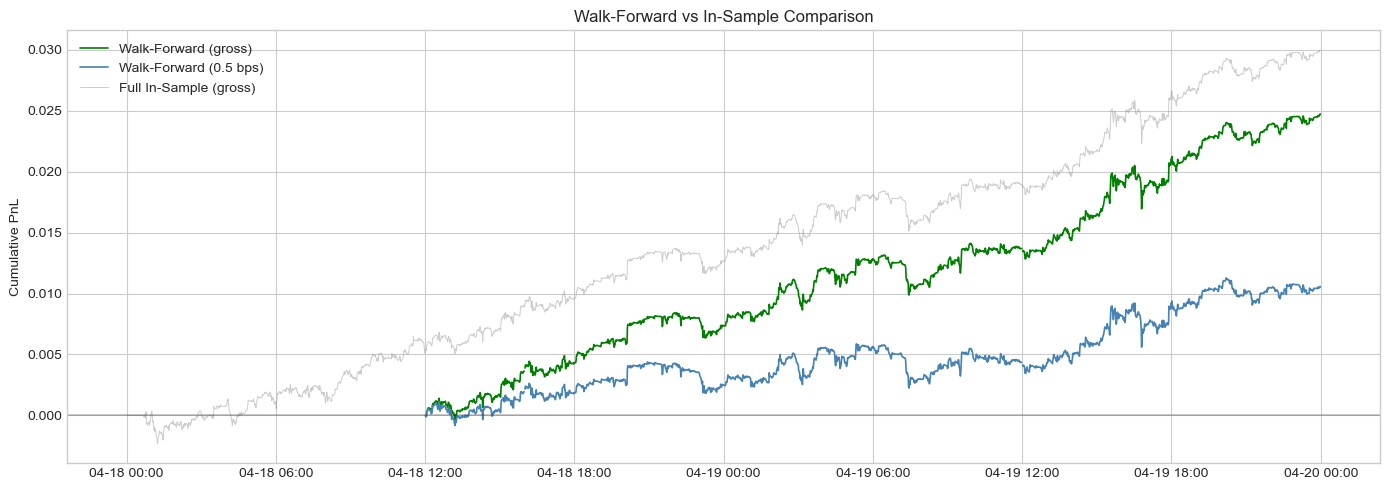

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(wf_result_gross.cumulative_pnl.index, wf_result_gross.cumulative_pnl.values, 
        linewidth=1.2, color='green', label='Walk-Forward (gross)')
ax.plot(wf_result_net.cumulative_pnl.index, wf_result_net.cumulative_pnl.values, 
        linewidth=1.2, color='steelblue', label='Walk-Forward (0.5 bps)')

is_result = results_gross['composite']
ax.plot(is_result.cumulative_pnl.index, is_result.cumulative_pnl.values, 
        linewidth=0.7, color='gray', alpha=0.4, label='Full In-Sample (gross)')

ax.set_ylabel('Cumulative PnL')
ax.set_title('Walk-Forward vs In-Sample Comparison')
ax.legend()
ax.axhline(0, color='black', linewidth=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 3.7 Drawdown Analysis

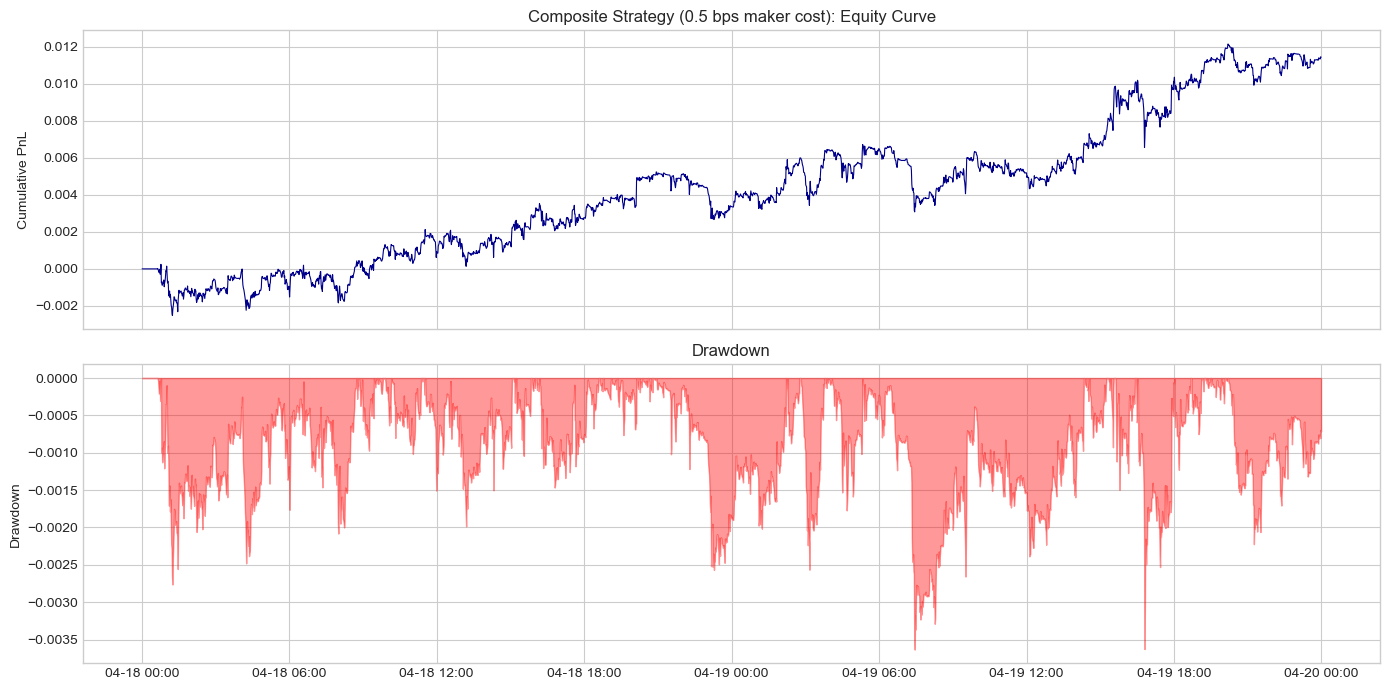

Max drawdown: -0.003634
Calmar ratio (PnL / MaxDD): 3.14


In [25]:
r_best = run_backtest(bars, composite_sig, cost_bps=0.5)
cum = r_best.cumulative_pnl
running_max = cum.cummax()
drawdown = cum - running_max

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(cum.index, cum.values, linewidth=0.8, color='darkblue')
axes[0].set_ylabel('Cumulative PnL')
axes[0].set_title('Composite Strategy (0.5 bps maker cost): Equity Curve')

axes[1].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4)
axes[1].set_ylabel('Drawdown')
axes[1].set_title('Drawdown')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

print(f"Max drawdown: {drawdown.min():.6f}")
print(f"Calmar ratio (PnL / MaxDD): {cum.iloc[-1] / abs(drawdown.min()):.2f}")

## 3.8 Hourly PnL Heatmap

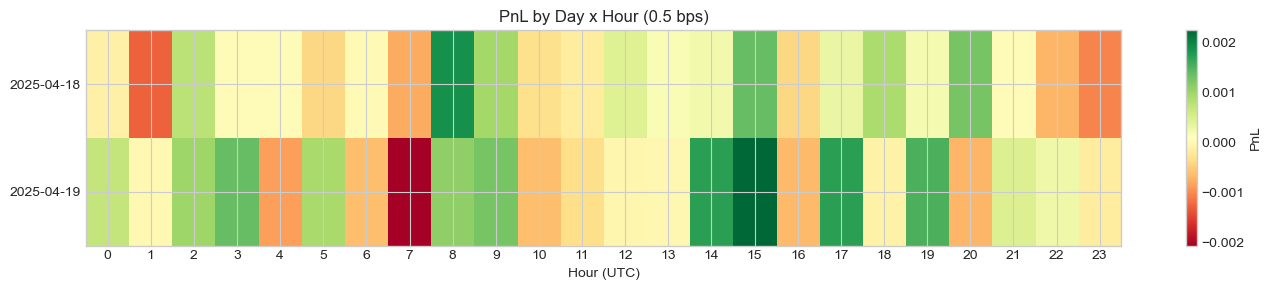

In [26]:
pnl_series = r_best.pnl
hourly_agg = pnl_series.groupby([pnl_series.index.date, pnl_series.index.hour]).sum().unstack()

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(hourly_agg.values, cmap='RdYlGn', aspect='auto')
ax.set_yticks(range(len(hourly_agg.index)))
ax.set_yticklabels([str(d) for d in hourly_agg.index])
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_xlabel('Hour (UTC)')
ax.set_title('PnL by Day x Hour (0.5 bps)')
plt.colorbar(im, ax=ax, label='PnL')
plt.tight_layout()
plt.show()

## 3.9 Conclusions

### Strategy Summary
- **Instrument**: BTCUSDT Perpetual Futures (Binance)
- **Bar size**: 1 minute
- **Target holding period**: 5–15 minutes
- **Signal count**: 8 individual signals combined into 1 composite
- **Signal types**: Mean reversion (4), contrarian microstructure (2), contrarian momentum (2)

### Key Results
1. **All 8 signals have positive IC** at the 5-min horizon after direction correction.
2. **Gross alpha is real**: Sharpe ~43 annualized at 1-min rebalance with zero cost.
3. **Execution cost is the binding constraint**: breakeven is ~0.75 bps round-trip.
   - Profitable with **maker orders** on Binance VIP tiers (0–0.5 bps).
   - Unprofitable with taker orders at 2+ bps.
4. **Mean-reversion dominant**: Consistent with negative short-lag autocorrelation in BTCUSDT.
5. **VWAP reversion and RSI** are the strongest individual signals.
6. **Order flow imbalance** (contrarian) adds orthogonal information.

### Execution Implications
- This is a **maker strategy**: must use limit orders to capture the spread rather than pay it.
- Requires low-latency infrastructure to post limit orders and manage queue position.
- Alpha decays rapidly with rebalance frequency — optimal at 1–3 min, minimal at 15 min.

### Limitations
- Only 2 days of data — insufficient for regime-change analysis or seasonal effects.
- No slippage or queue priority modeling — critical for maker strategies.
- Signal weights are heuristic — could be optimized via LASSO/ridge on a longer dataset.
- No intraday volume normalization.
- Could benefit from: funding rate, order book imbalance, cross-asset (ETH/SOL) signals.